## **FindMyText**: Document similarity index

In addition to the fingerprint inverted index used for text-containment detection, **FindMyText** can optionally compute an *exact* document-document similarity index during merging: for every pair of documents $(i, j)$, it stores

$$S(i, j) = |D_i \cap D_j|$$

the number of fingerprints shared between the two documents. This is useful for near-duplicate detection, clustering, or exploring which documents in a corpus overlap the most.

This is computed as a byproduct of the existing merge step: every fingerprint's posting list already groups the documents that share it. Similarity generation is optional.

### Creating a controlled corpus

Real corpora can contain unexpectedly large compilation documents, making raw overlap counts hard to interpret. This demo instead creates 50 short, deterministic documents with known relationships:

- `source-alpha` contains three distinct passages reused separately by three derivative documents.
- `alpha-copy-a` and `alpha-copy-b` also share a smaller bridge passage with each other.
- `source-beta` and two derivatives form a second cluster.
- `near-duplicate-a` and `near-duplicate-b` share most of their content.
- The remaining documents contain unique control text.

This gives us known positive and negative cases for graphs, cluster detection, passage localization, and exact-count verification.

In [1]:
import multiprocessing as mp
import os

# index_file's producer process passes a generator, which requires the "fork"
# start method (the default "forkserver" on some platforms/Python versions can't pickle it).
if os.name != "nt":
    mp.set_start_method("fork", force=True)


In [22]:
def make_passage(label: str, n_sentences: int = 50) -> str:
    return " ".join(
        " ".join(f"{label}{sentence:03d}t{token:02d}" for token in range(14))
        for sentence in range(n_sentences)
    )


def make_filler(doc_id: str, n_sentences: int = 20) -> str:
    namespace = "u" + doc_id.replace("-", "_")
    return " ".join(
        " ".join(f"{namespace}{sentence:03d}t{token:02d}" for token in range(14))
        for sentence in range(n_sentences)
    )


alpha_a = make_passage("aa")
alpha_b = make_passage("ab")
alpha_c = make_passage("ac")
alpha_bridge = make_passage("ax", n_sentences=20)

beta_a = make_passage("ba", n_sentences=40)
beta_b = make_passage("bb", n_sentences=40)
near_duplicate_core = make_passage("nd", n_sentences=60)

corpus = [
    {"id": "source-alpha", "text": make_filler("source-alpha") + " " + alpha_a + " " + alpha_b + " " + alpha_c},
    {"id": "alpha-copy-a", "text": make_filler("alpha-copy-a") + " " + alpha_a + " " + alpha_bridge},
    {"id": "alpha-copy-b", "text": make_filler("alpha-copy-b") + " " + alpha_b + " " + alpha_bridge},
    {"id": "alpha-copy-c", "text": make_filler("alpha-copy-c") + " " + alpha_c},
    {"id": "source-beta", "text": make_filler("source-beta") + " " + beta_a + " " + beta_b},
    {"id": "beta-copy-a", "text": make_filler("beta-copy-a") + " " + beta_a},
    {"id": "beta-copy-b", "text": make_filler("beta-copy-b") + " " + beta_b},
    {"id": "near-duplicate-a", "text": make_filler("near-duplicate-a") + " " + near_duplicate_core},
    {"id": "near-duplicate-b", "text": make_filler("near-duplicate-b") + " " + near_duplicate_core},
]

for i in range(50 - len(corpus)):
    doc_id = f"control-{i:02d}"
    corpus.append({"id": doc_id, "text": make_filler(doc_id, n_sentences=35)})

print(f"Created {len(corpus)} documents")
print(f"Length range: {min(len(row['text']) for row in corpus):,}–{max(len(row['text']) for row in corpus):,} characters")

Created 50 documents
Length range: 8,819–24,499 characters


`index_file` reads corpus records from a `.jsonl` file, so we write the 50 generated documents to disk:

In [23]:
import orjson

corpus_path = "similarity_demo_50.jsonl"
with open(corpus_path, "wb") as f:
    for row in corpus:
        f.write(orjson.dumps({"id": row["id"], "text": row["text"]}))
        f.write(b"\n")

### Building the index (Step 1: fingerprinting)

This is the same first step as in the main demo — extracting winnowed fingerprints for every document:

In [24]:
from findmytext import index_builder

index_builder.index_file(
    corpus_path,
    "similarity_demo_temp",
    nb_workers=4,
    max_length=250_000,
    delete_existing=True,
)

Indexing documents from similarity_demo_50.jsonl
Index files will be saved to similarity_demo_temp
Indexing stream with 4 fingerprint workers...
Nb documents: 50 kept, 0 skipped
Exporting index to similarity_demo_temp/final.mpk.gz...Done sorting. Now writing to file...Done.


['similarity_demo_temp/final.mpk.gz']

### Merging (Step 2), with similarities enabled

Passing `include_similarities=True` to `merge_indexes_from_dir` additionally writes a `similarities.npy` file alongside the usual index files. `similarity_chunk_size` bounds how many pair-counts are kept in memory before being flushed to a sorted chunk on disk, so memory stays bounded even for large corpora:

In [25]:
index_builder.merge_indexes_from_dir(
    "similarity_demo_temp",
    "similarity_demo_index",
    include_similarities=True,
    similarity_chunk_size=100_000,
)

# Once the index is built, you can remove the temporary index files.
!rm -rf similarity_demo_temp

Merging the following index files: ['similarity_demo_temp/final.mpk.gz']
Saving merged index to similarity_demo_index
Meta parameters: {'length': 4, 'window_size': 6, 'base': 256, 'punctuation': False}


Scanning doc IDs: 100%|██████████| 1/1 [00:00<00:00, 374.69it/s]

  Found 50 unique documents.
Saved document ID mapping for 50 documents.


Saving final index (7,579 fingerprints)...Done
Saved 7 document similarity pairs.


### Exploring the similarity scores

We load the merged index with `DiskBasedIndex`, which memory-maps `similarities.npy` if present:

In [26]:
from findmytext import indexing

index = indexing.DiskBasedIndex("similarity_demo_index")
print(f"Number of document pairs with at least one shared fingerprint: {len(index.similarities):,}")

Number of document pairs with at least one shared fingerprint: 7


In [27]:
with open(corpus_path, "rb") as f:
    id_to_text = {}
    for line in f:
        record = orjson.loads(line)
        id_to_text[record["id"]] = record["text"]

Not every pair of documents shares a fingerprint, so this number is typically lower than the total number of possible pairs $\binom{n}{2}$.

**Top overlapping document pairs across the whole corpus**, sorted by shared-fingerprint count:

In [28]:
import numpy as np

order = np.argsort(-index.similarities["count"])
print(f"{'Document A':>12}  {'Document B':>12}  {'Shared fingerprints':>20}")
for i in order[:10]:
    row = index.similarities[i]
    doc_a = index.to_external_doc_id[int(row["doc_i"])]
    doc_b = index.to_external_doc_id[int(row["doc_j"])]
    print(f"{doc_a:>12}  {doc_b:>12}  {int(row['count']):>20,}")

  Document A    Document B   Shared fingerprints
near-duplicate-a  near-duplicate-b                   244
source-alpha  alpha-copy-b                   203
source-alpha  alpha-copy-c                   198
source-alpha  alpha-copy-a                   191
 source-beta   beta-copy-b                   155
 source-beta   beta-copy-a                   147
alpha-copy-a  alpha-copy-b                    79


**Similarities for a single document**, via the `get_document_similarities` helper:

In [36]:
some_doc_id = "source-alpha"
matches = index.get_document_similarities(some_doc_id)

print(f"Documents sharing fingerprints with {some_doc_id}:")
for other_doc_id, count in sorted(matches.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {other_doc_id}: {count:,} shared fingerprints")

Documents sharing fingerprints with source-alpha:
  alpha-copy-b: 203 shared fingerprints
  alpha-copy-c: 198 shared fingerprints
  alpha-copy-a: 191 shared fingerprints


### Visualizing the similarity graph

We can turn the similarity index into a graph — documents are nodes, and an edge connects two documents whenever they share at least `min_similarity` fingerprints, weighted by the shared-fingerprint count. Node size reflects each document's *weighted degree* (its total overlap with all its neighbours).

Since the full graph can be dense, `max_documents` lets us keep only the documents with the highest weighted degree after filtering by `min_similarity`, so the busiest, most-overlapping documents remain visible.

This requires the optional `networkx` and `matplotlib` packages (`pip install findmytext[viz]`).


Full graph: 9 documents, 7 edges


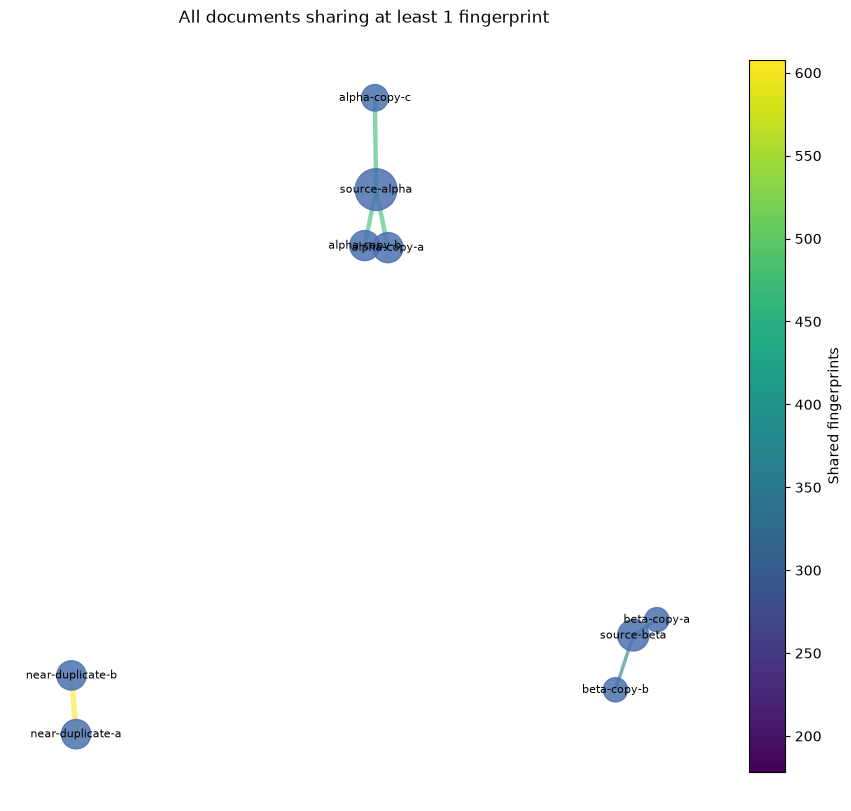

In [16]:
from findmytext import visualization

# Full graph: every document pair that shares at least one fingerprint.
full_graph = visualization.build_similarity_graph(index, min_similarity=1)
print(f"Full graph: {full_graph.number_of_nodes()} documents, {full_graph.number_of_edges()} edges")

fig = visualization.plot_similarity_graph(
    full_graph, title="All documents sharing at least 1 fingerprint"
)


The full graph is dense and hard to read for larger corpora. Filtering to pairs with at least 10 shared fingerprints, and keeping only the 15 documents with the highest resulting weighted degree, gives a clearer picture of the most similar clusters:


Filtered graph: 9 documents, 7 edges


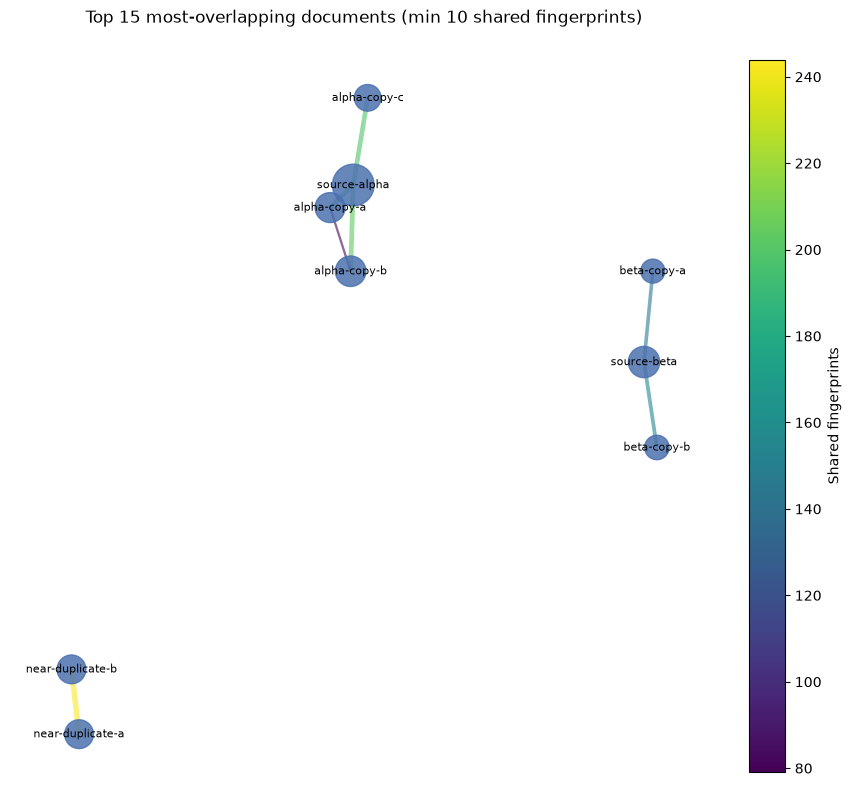

In [32]:
filtered_graph = visualization.build_similarity_graph(
    index, min_similarity=10, max_documents=15
)
print(
    f"Filtered graph: {filtered_graph.number_of_nodes()} documents, "
    f"{filtered_graph.number_of_edges()} edges"
)

fig = visualization.plot_similarity_graph(
    filtered_graph,
    title="Top 15 most-overlapping documents (min 10 shared fingerprints)",
)


### Finding the most important documents

Which documents overlap the most with *everyone else* combined? `rank_documents_by_node_strength` sums each document's shared-fingerprint counts across all its qualifying pairs (its *node strength*, i.e. weighted degree) and returns a sorted table:


In [17]:
node_strength = visualization.rank_documents_by_node_strength(index, min_similarity=1)
print("Top 10 documents by node strength:")
print(node_strength.head(10))


Top 10 documents by node strength:
shape: (9, 2)
┌──────────────────┬───────────────┐
│ doc_id           ┆ node_strength │
│ ---              ┆ ---           │
│ str              ┆ i64           │
╞══════════════════╪═══════════════╡
│ source-alpha     ┆ 1408          │
│ source-beta      ┆ 709           │
│ alpha-copy-a     ┆ 652           │
│ alpha-copy-b     ┆ 647           │
│ near-duplicate-a ┆ 608           │
│ near-duplicate-b ┆ 608           │
│ alpha-copy-c     ┆ 465           │
│ beta-copy-b      ┆ 359           │
│ beta-copy-a      ┆ 350           │
└──────────────────┴───────────────┘


### Documents sharing over 100 fingerprints

Raising `min_similarity` further isolates only the strongest overlaps, which is often the most reliable starting point for spotting near-duplicate or derivative content:


9 documents, 7 edges share over 100 fingerprints


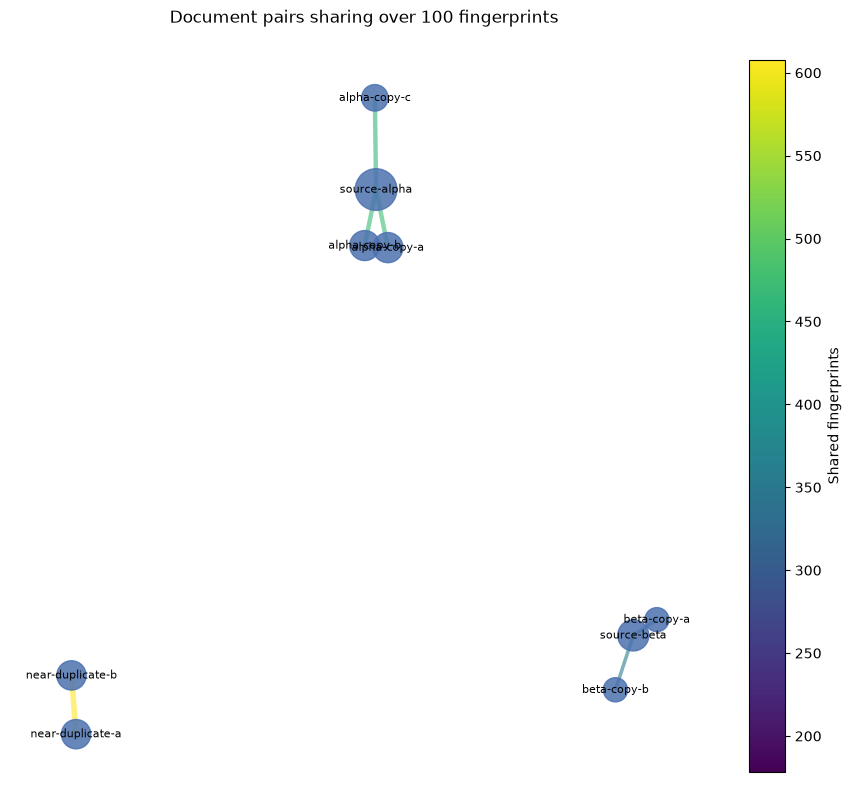

In [18]:
high_similarity_graph = visualization.build_similarity_graph(index, min_similarity=100)
print(
    f"{high_similarity_graph.number_of_nodes()} documents, "
    f"{high_similarity_graph.number_of_edges()} edges share over 100 fingerprints"
)

fig = visualization.plot_similarity_graph(
    high_similarity_graph, title="Document pairs sharing over 100 fingerprints"
)


### Investigating a self-chosen set of documents

You don't have to rely on automatic filtering — pass `doc_ids` to `build_similarity_graph` to inspect an exact, hand-picked set of documents. This bypasses `min_similarity`/`max_documents` filtering entirely, but a `UserWarning` is still raised for any pair among your chosen documents whose shared-fingerprint count is below `min_similarity`, so you don't silently include unrelated documents by mistake:


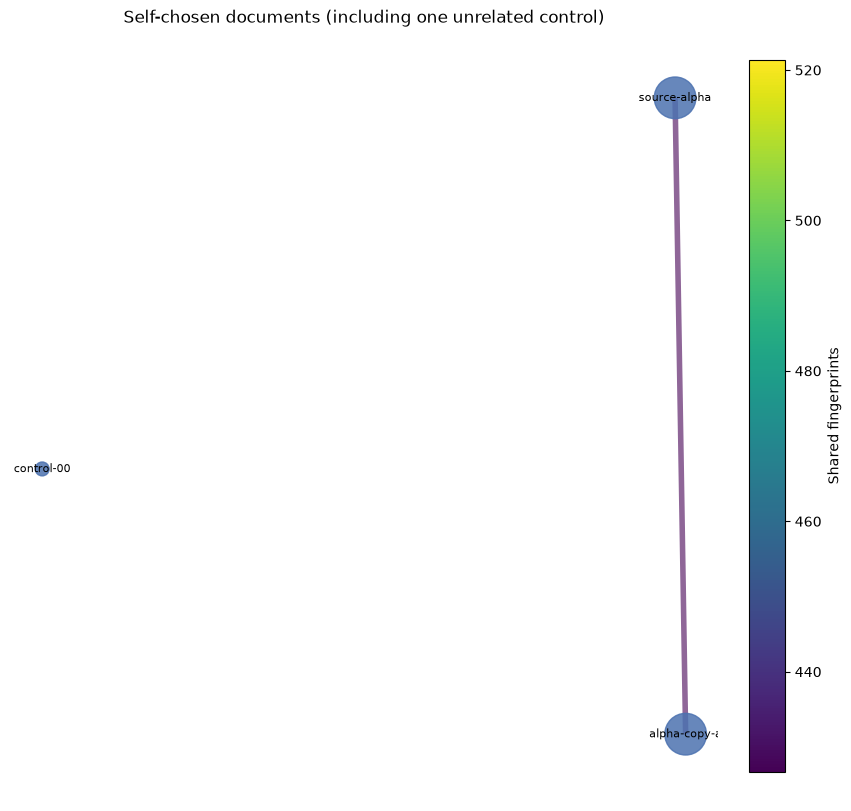

In [19]:
import warnings

selected_doc_ids = ["source-alpha", "alpha-copy-a", "control-00"]

with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    selection_graph = visualization.build_similarity_graph(
        index, doc_ids=selected_doc_ids, min_similarity=100
    )
    for warning in caught:
        print(f"WARNING: {warning.message}")

fig = visualization.plot_similarity_graph(
    selection_graph,
    title="Self-chosen documents (including one unrelated control)",
)

### Finding potential source-document clusters

Suppose several documents each reused text from a common source: Doc1, Doc2, and Doc3 all copied (and lightly edited) passages from Doc4. We'd expect (Doc1, Doc4), (Doc2, Doc4), and (Doc3, Doc4) to have *higher* similarity than Doc1, Doc2, and Doc3 have with *each other* — a "star" pattern centered on the common source.

`find_potential_source_clusters` looks for this pattern automatically:
1. Build a similarity graph restricted to edges with at least `min_similarity` shared fingerprints.
2. For each connected component of at least `min_cluster_size` documents, pick the highest node-strength document as the candidate "hub" (common source).
3. Flag the component if the hub's average similarity to the other members is at least `hub_dominance_ratio` times higher than those members' average similarity to *each other*.

This is a heuristic for prioritising documents for closer inspection, not proof of copying direction. Running it on our corpus surfaces exactly this kind of cluster:


Found 2 flagged cluster(s):
{'hub': 'source-alpha', 'members': ['alpha-copy-a', 'alpha-copy-c', 'alpha-copy-b'], 'component_size': 4, 'hub_mean_weight': 197.33333333333334, 'internal_mean_weight': 0.0, 'dominance_ratio': inf}
{'hub': 'source-beta', 'members': ['beta-copy-a', 'beta-copy-b'], 'component_size': 3, 'hub_mean_weight': 151.0, 'internal_mean_weight': 0.0, 'dominance_ratio': inf}


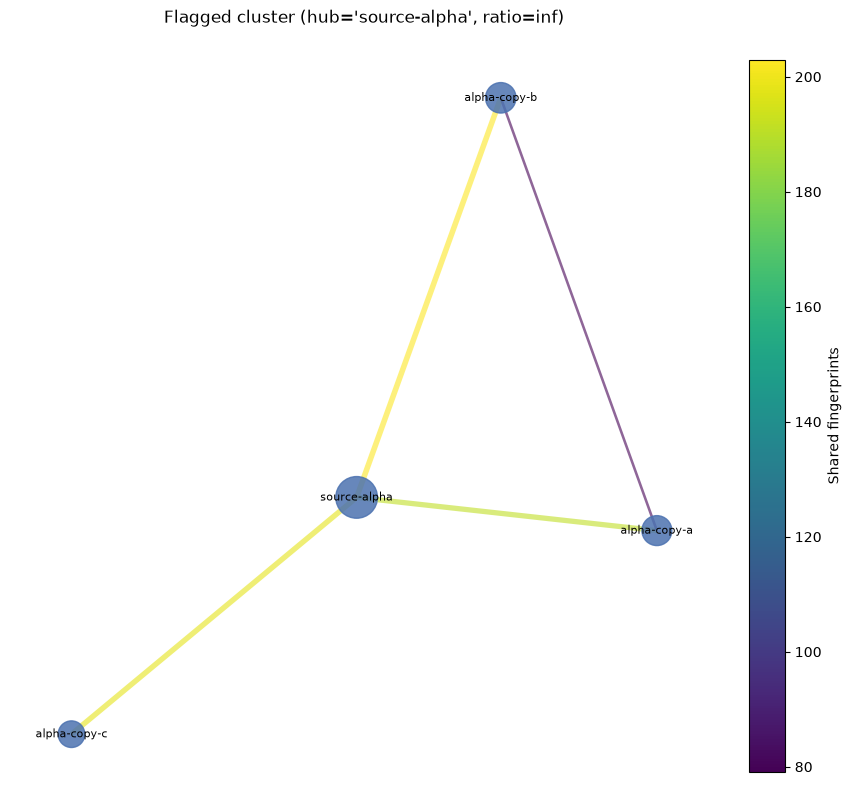

In [29]:
clusters = visualization.find_potential_source_clusters(
    index, min_similarity=120, min_cluster_size=3, hub_dominance_ratio=1.3
)
print(f"Found {len(clusters)} flagged cluster(s):")
for cluster in clusters:
    print(cluster)

# Visualize the top flagged cluster (hub + members).
top_cluster = clusters[0]
cluster_doc_ids = [top_cluster["hub"]] + top_cluster["members"]
cluster_graph = visualization.build_similarity_graph(
    index, doc_ids=cluster_doc_ids, min_similarity=0
)
fig = visualization.plot_similarity_graph(
    cluster_graph,
    title=f"Flagged cluster (hub={top_cluster['hub']!r}, ratio={top_cluster['dominance_ratio']:.2f})",
)

### Investigating shared passages within a cluster

A flagged cluster only tells us *that* several documents overlap heavily with a hub — not *where*. Doc1 might have copied an early chapter of the hub while Doc3 copied a later one, so a high similarity *count* alone doesn't tell us whether the reused passages are the same or different.

Running the Smith-Waterman aligner (`findmytext.oracle`) over *full* documents to find out is expensive — that's exactly the problem `detectors.FingerprintChainDetector` (used internally by `findmytext.web.TextContainmentDetector`) already solves for detection. `analyze_shared_passages` reuses that same fingerprint-clustering machinery via `locate_shared_passage` to first narrow each hub/member pair down to a small excerpt around their *largest shared-fingerprint chain*, and only runs the aligner on that excerpt — not the full text. It then reports the character-offset span in the hub document covered by the resulting aligned region(s):


shape: (3, 5)
┌──────────────┬───────────┬───────────┬─────────┬─────────────────────┐
│ doc_id       ┆ n_regions ┆ hub_start ┆ hub_end ┆ total_matched_chars │
│ ---          ┆ ---       ┆ ---       ┆ ---     ┆ ---                 │
│ str          ┆ i64       ┆ i64       ┆ i64     ┆ i64                 │
╞══════════════╪═══════════╪═══════════╪═════════╪═════════════════════╡
│ alpha-copy-a ┆ 1         ┆ 5412      ┆ 12081   ┆ 6669                │
│ alpha-copy-c ┆ 1         ┆ 18195     ┆ 24499   ┆ 6304                │
│ alpha-copy-b ┆ 1         ┆ 11895     ┆ 18399   ┆ 6504                │
└──────────────┴───────────┴───────────┴─────────┴─────────────────────┘


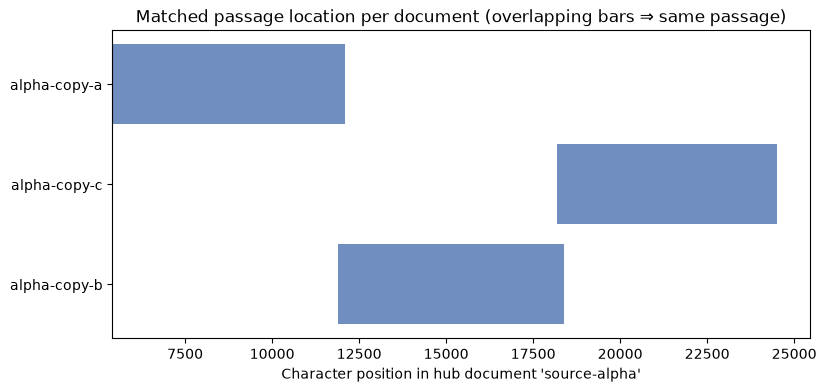

In [30]:
passage_summary = visualization.analyze_shared_passages(
    index, id_to_text, hub_doc_id=top_cluster["hub"], other_doc_ids=top_cluster["members"]
)
print(passage_summary)

fig = visualization.plot_shared_passage_overlap(passage_summary, hub_doc_id=top_cluster["hub"])


In [37]:
from findmytext import winnower

query_winnower = winnower.Winnower(
    length=index.winnower.length,
    window_size=index.winnower.window_size,
    base=index.winnower.base,
    punctuation=index.winnower.punctuation,
)

fp_counts = {
    doc_id: len(query_winnower.get_winnowed_fingerprints(id_to_text[doc_id])[0])
    for doc_id in id_to_text
}
print("Length / fingerprint-count range across corpus:")
print("  min:", min(fp_counts.values()), "max:", max(fp_counts.values()))

rows = []
for doc_a, doc_matches in (
    (doc_id, index.get_document_similarities(doc_id)) for doc_id in fp_counts
):
    for doc_b, count in doc_matches.items():
        if doc_a < doc_b:
            smaller = min(fp_counts[doc_a], fp_counts[doc_b])
            rows.append((doc_a, doc_b, count, count / smaller))

rows.sort(key=lambda row: row[3], reverse=True)
print(f"\n{'Doc A':>18} {'Doc B':>18} {'Shared':>10} {'Fraction of smaller doc':>25}")
for doc_a, doc_b, count, fraction in rows[:10]:
    print(f"{doc_a:>18} {doc_b:>18} {count:>10} {fraction:>25.4f}")

Length / fingerprint-count range across corpus:
  min: 129 max: 669

             Doc A              Doc B     Shared   Fraction of smaller doc
  near-duplicate-a   near-duplicate-b        244                    0.7508
      alpha-copy-c       source-alpha        198                    0.7148
       beta-copy-b        source-beta        155                    0.6681
       beta-copy-a        source-beta        147                    0.6562
      alpha-copy-b       source-alpha        203                    0.5562
      alpha-copy-a       source-alpha        191                    0.5473
      alpha-copy-a       alpha-copy-b         79                    0.2264


If the bars above overlap, the documents likely reused the *same* passage of the hub; non-overlapping bars point to *different* passages. For a closer look at one specific pair, `show_pairwise_alignment` displays a colour-coded, character-level diff (also computed on the narrowed-down excerpt, not the full documents):


In [34]:
_ = visualization.show_pairwise_alignment(
    index, id_to_text, top_cluster["hub"], top_cluster["members"][0]
)


### Verifying the similarity counts

As a sanity check, we can independently recompute the winnowed fingerprints for a couple of documents and manually count the intersection, comparing it against what was stored in `similarities.npy`:

In [38]:
from findmytext import winnower

fingerprint_generator = winnower.Winnower(length=4, window_size=6)


def manual_shared_fingerprint_count(doc_id_a: str, doc_id_b: str) -> int:
    fps_a, _ = fingerprint_generator.get_winnowed_fingerprints(id_to_text[doc_id_a])
    fps_b, _ = fingerprint_generator.get_winnowed_fingerprints(id_to_text[doc_id_b])
    return len(set(fps_a.tolist()) & set(fps_b.tolist()))


# Verify a handful of pairs, including the top match found above.
top_row = index.similarities[order[0]]
doc_a = index.to_external_doc_id[int(top_row["doc_i"])]
doc_b = index.to_external_doc_id[int(top_row["doc_j"])]

pairs_to_check = [(doc_a, doc_b)] + [
    (some_doc_id, other) for other, _ in list(matches.items())[:3]
]
for doc_id_a, doc_id_b in pairs_to_check:
    manual_count = manual_shared_fingerprint_count(doc_id_a, doc_id_b)
    stored_count = index.get_document_similarities(doc_id_a).get(doc_id_b, 0)
    status = "OK" if manual_count == stored_count else "MISMATCH"
    print(f"{doc_id_a} <-> {doc_id_b}: manual={manual_count}, stored={stored_count}  [{status}]")


near-duplicate-a <-> near-duplicate-b: manual=244, stored=244  [OK]
source-alpha <-> alpha-copy-a: manual=191, stored=191  [OK]
source-alpha <-> alpha-copy-b: manual=203, stored=203  [OK]
source-alpha <-> alpha-copy-c: manual=198, stored=198  [OK]


### Large-scale verification

For a more thorough check, `verify_similarity_counts` samples `check_n_documents` unique documents (every indexed document when the requested number is larger than the corpus), independently recomputes their fingerprints, and cross-checks every pairwise count against the stored index. Missing sparse-index entries correctly count as zero. Progress is printed every ~10%, and every mismatch raises a warning.

This cell was run once and then commented out so reopening the notebook does not repeat the expensive verification. The recorded result was:

```text
Checking 50 documents -> 1,225 pairs to verify.
  ... 10% (123/1,225 pairs)
  ... 20% (245/1,225 pairs)
  ... 30% (368/1,225 pairs)
  ... 40% (490/1,225 pairs)
  ... 50% (613/1,225 pairs)
  ... 60% (735/1,225 pairs)
  ... 70% (858/1,225 pairs)
  ... 80% (980/1,225 pairs)
  ... 90% (1,103/1,225 pairs)
  ... 100% (1,225/1,225 pairs)
Done: checked 1,225 pairs across 50 documents, found 0 mismatch(es).
```

In [ ]:
# verification_summary = visualization.verify_similarity_counts(
#     index,
#     id_to_text,
#     check_n_documents=len(id_to_text),
#     seed=0,
# )
# print(verification_summary)

### Command-line equivalent

The generated JSONL corpus can be indexed from the command line with the same two steps:

```bash
python -m findmytext.index_builder index similarity_demo_50.jsonl similarity_demo_temp --nb_workers 4 --max_length 250000
python -m findmytext.index_builder merge similarity_demo_temp similarity_demo_index --include-similarities
```